In [2]:
import pandas as pd

df = pd.read_csv("browsing_history.csv")

print(df.head())
print(df.info())

             timestamp                 domain category  \
0  2026-03-10T00:35:10      sqlitebrowser.org   coding   
1  2026-03-10T07:27:13          tidbcloud.com  utility   
2  2026-03-10T07:33:55  support.microsoft.com  utility   
3  2026-03-10T07:48:46             github.com   coding   
4  2026-03-10T08:01:37     auth.tidbcloud.com  utility   

                           title  hour        date day_name  
0      Page on sqlitebrowser.org     0  2026-03-10  Tuesday  
1          Page on tidbcloud.com     7  2026-03-10  Tuesday  
2  Page on support.microsoft.com     7  2026-03-10  Tuesday  
3             Page on github.com     7  2026-03-10  Tuesday  
4     Page on auth.tidbcloud.com     8  2026-03-10  Tuesday  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  634 non-null    object
 1   domain     634 non-null    object
 2   category   634

In [3]:
df.head()

,timestamp,domain,category,title,hour,date,day_name
0,2026-03-10T00:35:10,sqlitebrowser.org,coding,Page on sqlitebrowser.org,0,2026-03-10,Tuesday
1,2026-03-10T07:27:13,tidbcloud.com,utility,Page on tidbcloud.com,7,2026-03-10,Tuesday
2,2026-03-10T07:33:55,support.microsoft.com,utility,Page on support.microsoft.com,7,2026-03-10,Tuesday
3,2026-03-10T07:48:46,github.com,coding,Page on github.com,7,2026-03-10,Tuesday
4,2026-03-10T08:01:37,auth.tidbcloud.com,utility,Page on auth.tidbcloud.com,8,2026-03-10,Tuesday


In [4]:
df1 = pd.read_csv("ram_log.csv")

In [5]:
df.head()

,timestamp,domain,category,title,hour,date,day_name
0,2026-03-10T00:35:10,sqlitebrowser.org,coding,Page on sqlitebrowser.org,0,2026-03-10,Tuesday
1,2026-03-10T07:27:13,tidbcloud.com,utility,Page on tidbcloud.com,7,2026-03-10,Tuesday
2,2026-03-10T07:33:55,support.microsoft.com,utility,Page on support.microsoft.com,7,2026-03-10,Tuesday
3,2026-03-10T07:48:46,github.com,coding,Page on github.com,7,2026-03-10,Tuesday
4,2026-03-10T08:01:37,auth.tidbcloud.com,utility,Page on auth.tidbcloud.com,8,2026-03-10,Tuesday


In [6]:
df1.head()

,timestamp,ram_used_mb,ram_available_mb,browser_ram_mb,cpu_percent
0,2026-03-10T00:00:00,5620.1,10763.9,930.2,64.4
1,2026-03-10T00:00:10,6518.9,9865.1,803.1,28.7
2,2026-03-10T00:00:20,5852.4,10531.6,859.6,23.9
3,2026-03-10T00:00:30,5386.7,10997.3,808.3,66.9
4,2026-03-10T00:00:40,5960.8,10423.2,866.8,48.0


In [7]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df1["timestamp"] = pd.to_datetime(df1["timestamp"])

In [8]:
df = df.sort_values("timestamp")
df1 = df1.sort_values("timestamp")

In [9]:
merged_df = pd.merge_asof(
    df,
    df1,
    on="timestamp",
    direction="nearest"
)

In [10]:
merged_df = pd.merge_asof(
    df,
    df1,
    on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("1min")
)

In [11]:
# Ensure timestamp is datetime
merged_df["timestamp"] = pd.to_datetime(merged_df["timestamp"])

# Sort
merged_df = merged_df.sort_values("timestamp")

# Derived time features
merged_df["hour"] = merged_df["timestamp"].dt.hour
merged_df["day"] = merged_df["timestamp"].dt.day
merged_df["weekday"] = merged_df["timestamp"].dt.weekday
merged_df["is_weekend"] = merged_df["weekday"].isin([5,6]).astype(int)

# Time difference between events
merged_df["time_diff"] = merged_df["timestamp"].diff().dt.total_seconds()

merged_df.head()

,timestamp,domain,category,title,hour,date,day_name,ram_used_mb,ram_available_mb,browser_ram_mb,cpu_percent,day,weekday,is_weekend,time_diff
0,2026-03-10 00:35:10,sqlitebrowser.org,coding,Page on sqlitebrowser.org,0,2026-03-10,Tuesday,4336.3,12047.7,596.4,33.2,10,1,0,NaN
1,2026-03-10 07:27:13,tidbcloud.com,utility,Page on tidbcloud.com,7,2026-03-10,Tuesday,5074.1,11309.9,738.0,29.9,10,1,0,24723.0
2,2026-03-10 07:33:55,support.microsoft.com,utility,Page on support.microsoft.com,7,2026-03-10,Tuesday,5046.4,11337.6,850.5,50.9,10,1,0,402.0
3,2026-03-10 07:48:46,github.com,coding,Page on github.com,7,2026-03-10,Tuesday,5375.3,11008.7,752.3,7.4,10,1,0,891.0
4,2026-03-10 08:01:37,auth.tidbcloud.com,utility,Page on auth.tidbcloud.com,8,2026-03-10,Tuesday,4336.9,12047.1,775.2,23.1,10,1,0,771.0


In [12]:
merged_df = merged_df.drop(columns=["time_diff"])

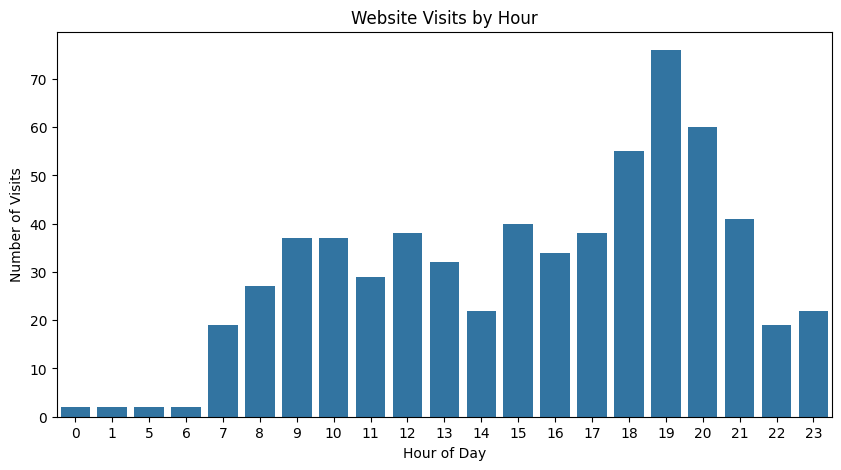

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

hour_counts = merged_df["hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.barplot(x=hour_counts.index, y=hour_counts.values)

plt.title("Website Visits by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Visits")

plt.show()

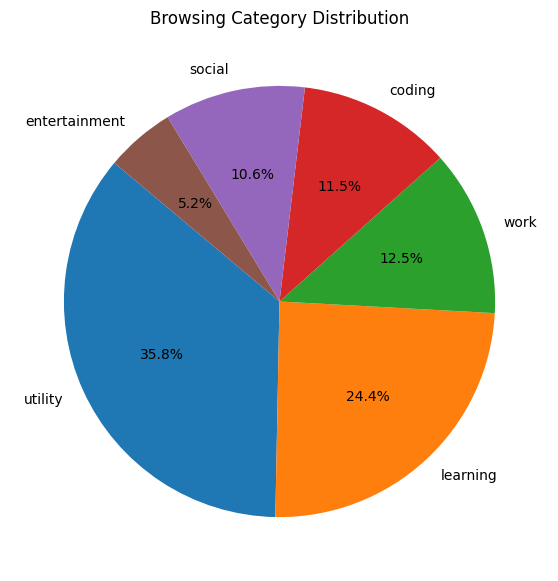

In [14]:
category_counts = merged_df["category"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Browsing Category Distribution")

plt.show()

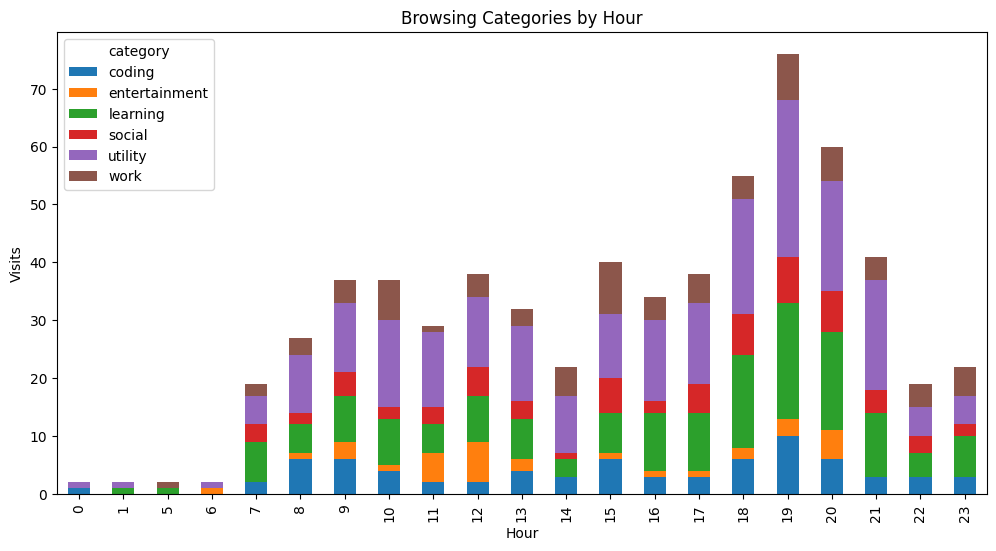

In [15]:
hour_category = merged_df.groupby(["hour","category"]).size().unstack().fillna(0)

hour_category.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Browsing Categories by Hour")
plt.xlabel("Hour")
plt.ylabel("Visits")

plt.show()

In [16]:
merged_df.to_csv("merged_data.csv", index=False)

In [17]:
import pandas as pd

df = pd.read_csv("/content/merged_data.csv")

df.head()

,timestamp,domain,category,title,hour,date,day_name,ram_used_mb,ram_available_mb,browser_ram_mb,cpu_percent,day,weekday,is_weekend
0,2026-03-10 00:35:10,sqlitebrowser.org,coding,Page on sqlitebrowser.org,0,2026-03-10,Tuesday,4336.3,12047.7,596.4,33.2,10,1,0
1,2026-03-10 07:27:13,tidbcloud.com,utility,Page on tidbcloud.com,7,2026-03-10,Tuesday,5074.1,11309.9,738.0,29.9,10,1,0
2,2026-03-10 07:33:55,support.microsoft.com,utility,Page on support.microsoft.com,7,2026-03-10,Tuesday,5046.4,11337.6,850.5,50.9,10,1,0
3,2026-03-10 07:48:46,github.com,coding,Page on github.com,7,2026-03-10,Tuesday,5375.3,11008.7,752.3,7.4,10,1,0
4,2026-03-10 08:01:37,auth.tidbcloud.com,utility,Page on auth.tidbcloud.com,8,2026-03-10,Tuesday,4336.9,12047.1,775.2,23.1,10,1,0


In [18]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

In [19]:
# calculate time difference between rows
df["time_diff"] = df["timestamp"].diff().dt.total_seconds().fillna(0)

# new session if gap > 15 minutes
SESSION_GAP = 15 * 60

df["new_session"] = (df["time_diff"] > SESSION_GAP).astype(int)

# assign session ids
df["session_id"] = df["new_session"].cumsum()

df.head()

,timestamp,domain,category,title,hour,date,day_name,ram_used_mb,ram_available_mb,browser_ram_mb,cpu_percent,day,weekday,is_weekend,time_diff,new_session,session_id
0,2026-03-10 00:35:10,sqlitebrowser.org,coding,Page on sqlitebrowser.org,0,2026-03-10,Tuesday,4336.3,12047.7,596.4,33.2,10,1,0,0.0,0,0
1,2026-03-10 07:27:13,tidbcloud.com,utility,Page on tidbcloud.com,7,2026-03-10,Tuesday,5074.1,11309.9,738.0,29.9,10,1,0,24723.0,1,1
2,2026-03-10 07:33:55,support.microsoft.com,utility,Page on support.microsoft.com,7,2026-03-10,Tuesday,5046.4,11337.6,850.5,50.9,10,1,0,402.0,0,1
3,2026-03-10 07:48:46,github.com,coding,Page on github.com,7,2026-03-10,Tuesday,5375.3,11008.7,752.3,7.4,10,1,0,891.0,0,1
4,2026-03-10 08:01:37,auth.tidbcloud.com,utility,Page on auth.tidbcloud.com,8,2026-03-10,Tuesday,4336.9,12047.1,775.2,23.1,10,1,0,771.0,0,1


In [20]:
session_features = df.groupby("session_id").agg(
    start_time=("timestamp","min"),
    end_time=("timestamp","max"),
    duration=("timestamp", lambda x: (x.max()-x.min()).total_seconds()/60),
    pages=("domain","count"),
    unique_domains=("domain","nunique"),
    avg_ram=("ram_used_mb","mean"),
    avg_cpu=("cpu_percent","mean"),
    top_category=("category",lambda x: x.mode()[0] if len(x.mode())>0 else "unknown")
).reset_index()

session_features.head()

,session_id,start_time,end_time,duration,pages,unique_domains,avg_ram,avg_cpu,top_category
0,0,2026-03-10 00:35:10,2026-03-10 00:35:10,0.000000,1,1,4336.300000,33.200000,coding
1,1,2026-03-10 07:27:13,2026-03-10 11:34:53,247.666667,39,24,6626.761538,49.464103,utility
2,2,2026-03-10 11:57:03,2026-03-10 12:13:03,16.000000,3,3,7279.066667,34.266667,learning
3,3,2026-03-10 12:42:45,2026-03-10 12:47:34,4.816667,3,2,6829.466667,29.533333,learning
4,4,2026-03-10 13:02:39,2026-03-10 13:43:55,41.266667,10,10,7435.420000,59.290000,utility


In [23]:
total_sessions = session_features["session_id"].nunique()
print("Total sessions:", total_sessions)

Total sessions: 105


In [24]:
ram_by_category = (
    session_features
    .groupby("top_category")["avg_ram"]
    .mean()
    .sort_values(ascending=False)
)

print("RAM by category")
print(ram_by_category)

RAM by category
top_category
utility          7265.050699
learning         7037.501875
entertainment    6824.518571
coding           6737.183492
social           6736.692000
work             6729.484609
Name: avg_ram, dtype: float64


In [25]:
top5_ram_categories = ram_by_category.head(5)

print("📊 RAM by Category (Top 5):")
print(top5_ram_categories)

📊 RAM by Category (Top 5):
top_category
utility          7265.050699
learning         7037.501875
entertainment    6824.518571
coding           6737.183492
social           6736.692000
Name: avg_ram, dtype: float64


In [26]:
top3_memory_categories = ram_by_category.head(3)

print("\n🧠 Top 3 memory-heavy categories:")
print(top3_memory_categories)


🧠 Top 3 memory-heavy categories:
top_category
utility          7265.050699
learning         7037.501875
entertainment    6824.518571
Name: avg_ram, dtype: float64


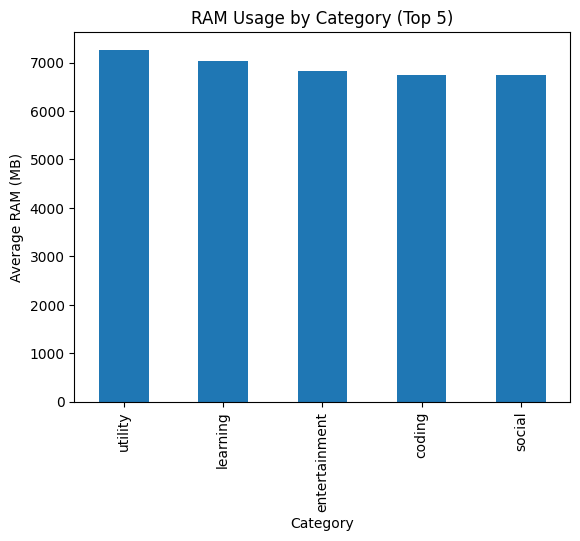

In [27]:
import matplotlib.pyplot as plt

top5_ram_categories.plot(kind="bar")
plt.title("RAM Usage by Category (Top 5)")
plt.ylabel("Average RAM (MB)")
plt.xlabel("Category")
plt.show()

In [28]:
features = session_features[[
    "duration",
    "pages",
    "unique_domains",
    "avg_ram",
    "avg_cpu"
]]

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

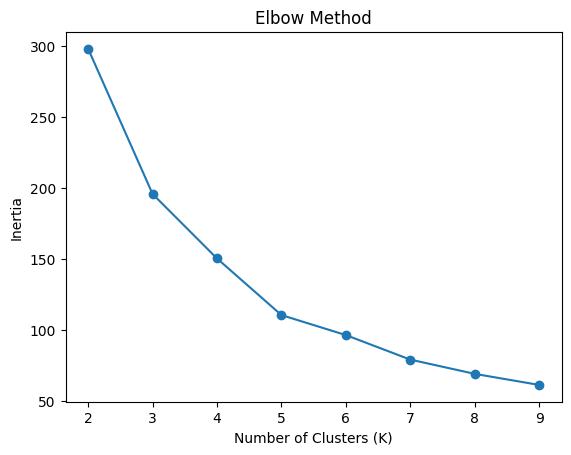

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

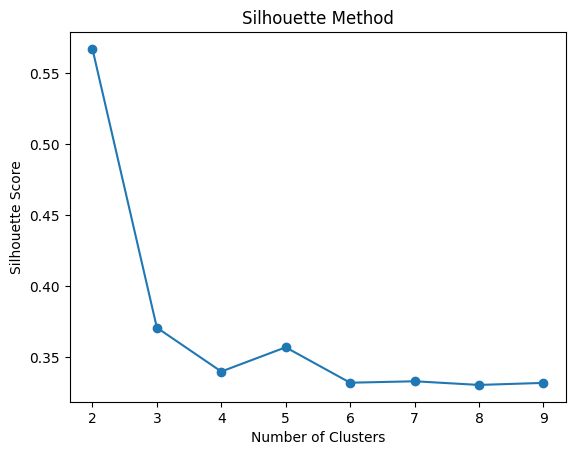

In [31]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2,10), sil_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [32]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

session_features["cluster"] = kmeans.fit_predict(X_scaled)

session_features.head()

,session_id,start_time,end_time,duration,pages,unique_domains,avg_ram,avg_cpu,top_category,cluster
0,0,2026-03-10 00:35:10,2026-03-10 00:35:10,0.000000,1,1,4336.300000,33.200000,coding,1
1,1,2026-03-10 07:27:13,2026-03-10 11:34:53,247.666667,39,24,6626.761538,49.464103,utility,3
2,2,2026-03-10 11:57:03,2026-03-10 12:13:03,16.000000,3,3,7279.066667,34.266667,learning,2
3,3,2026-03-10 12:42:45,2026-03-10 12:47:34,4.816667,3,2,6829.466667,29.533333,learning,1
4,4,2026-03-10 13:02:39,2026-03-10 13:43:55,41.266667,10,10,7435.420000,59.290000,utility,2


In [34]:
cluster_summary = session_features.groupby("cluster").mean(numeric_only=True)

print(cluster_summary)

         session_id    duration      pages  unique_domains      avg_ram  \
cluster                                                                   
0         53.678571    6.907143   2.500000        2.392857  7528.059048   
1         49.846154    3.868590   1.961538        1.846154  5774.402131   
2         53.066667   28.657037   6.466667        5.844444  7307.329063   
3         45.500000  172.866667  37.000000       22.833333  7589.742832   

           avg_cpu  
cluster             
0        70.789286  
1        27.107625  
2        45.007317  
3        56.843638  


In [35]:
cluster_summary = session_features.groupby("cluster")[[
    "duration",
    "pages",
    "unique_domains",
    "avg_ram",
    "avg_cpu"
]].mean()

print(cluster_summary)

           duration      pages  unique_domains      avg_ram    avg_cpu
cluster                                                               
0          6.907143   2.500000        2.392857  7528.059048  70.789286
1          3.868590   1.961538        1.846154  5774.402131  27.107625
2         28.657037   6.466667        5.844444  7307.329063  45.007317
3        172.866667  37.000000       22.833333  7589.742832  56.843638


In [36]:
category_dist = session_features.groupby("cluster")["top_category"].value_counts()

print(category_dist)

cluster  top_category 
0        utility           9
         learning          7
         work              5
         coding            4
         social            2
         entertainment     1
1        learning          9
         coding            5
         work              5
         utility           3
         entertainment     2
         social            2
2        utility          17
         learning         15
         coding            6
         work              4
         entertainment     2
         social            1
3        utility           5
         learning          1
Name: count, dtype: int64


In [37]:
cluster_summary = session_features.groupby("cluster").agg({
    "duration": "mean",
    "pages": "mean",
    "unique_domains": "mean",
    "avg_ram": "mean",
    "avg_cpu": "mean",
    "session_id": "count"
}).rename(columns={"session_id":"num_sessions"})

print(cluster_summary)

           duration      pages  unique_domains      avg_ram    avg_cpu  \
cluster                                                                  
0          6.907143   2.500000        2.392857  7528.059048  70.789286   
1          3.868590   1.961538        1.846154  5774.402131  27.107625   
2         28.657037   6.466667        5.844444  7307.329063  45.007317   
3        172.866667  37.000000       22.833333  7589.742832  56.843638   

         num_sessions  
cluster                
0                  28  
1                  26  
2                  45  
3                   6  


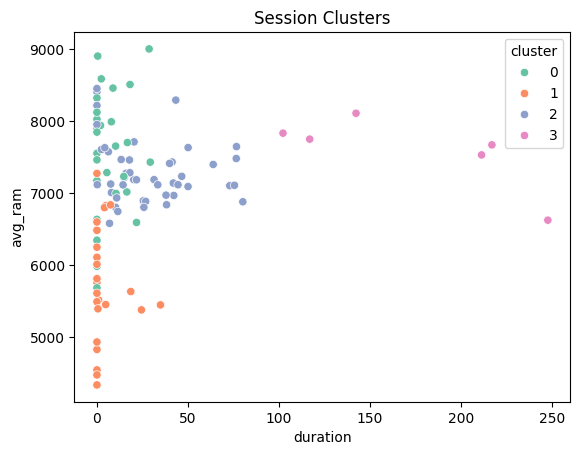

In [38]:
import seaborn as sns

sns.scatterplot(
    data=session_features,
    x="duration",
    y="avg_ram",
    hue="cluster",
    palette="Set2"
)
plt.title("Session Clusters")
plt.show()

In [39]:
session_features.to_csv("session_clusters.csv", index=False)

In [41]:
print(df.columns)

Index(['timestamp', 'domain', 'category', 'title', 'hour', 'date', 'day_name',
       'ram_used_mb', 'ram_available_mb', 'browser_ram_mb', 'cpu_percent',
       'day', 'weekday', 'is_weekend', 'time_diff', 'new_session',
       'session_id'],
      dtype='object')


In [42]:
import pandas as pd

df['timestamp'] = pd.to_datetime(df['timestamp'])

sessions = df.groupby("session_id").agg(
    start_time=('timestamp','min'),
    end_time=('timestamp','max'),
    pages=('domain','count'),
    unique_domains=('domain','nunique'),
    avg_ram=('browser_ram_mb','mean'),
    avg_cpu=('cpu_percent','mean'),
    top_category=('category', lambda x: x.mode()[0])
).reset_index()

sessions["duration_min"] = (sessions["end_time"] - sessions["start_time"]).dt.total_seconds()/60

print(sessions.head())

   session_id          start_time            end_time  pages  unique_domains  \
0           0 2026-03-10 00:35:10 2026-03-10 00:35:10      1               1   
1           1 2026-03-10 07:27:13 2026-03-10 11:34:53     39              24   
2           2 2026-03-10 11:57:03 2026-03-10 12:13:03      3               3   
3           3 2026-03-10 12:42:45 2026-03-10 12:47:34      3               2   
4           4 2026-03-10 13:02:39 2026-03-10 13:43:55     10              10   

      avg_ram    avg_cpu top_category  duration_min  
0  596.400000  33.200000       coding      0.000000  
1  902.166667  49.464103      utility    247.666667  
2  952.266667  34.266667     learning     16.000000  
3  957.033333  29.533333     learning      4.816667  
4  990.330000  59.290000      utility     41.266667  


In [43]:
features = sessions[
[
"duration_min",
"pages",
"unique_domains",
"avg_ram",
"avg_cpu"
]
]

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features)

In [45]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_dim = X.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation="relu")(input_layer)
encoded = Dense(4, activation="relu")(encoded)

decoded = Dense(8, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.fit(X, X, epochs=50, batch_size=16)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.1466
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1204 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0973 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0768 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0607 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0451 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0315 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0203 
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0103 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0017 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9939 
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9873 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9811 
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9760 
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9703 
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━

In [46]:
import numpy as np

recon = autoencoder.predict(X)

mse = np.mean(np.power(X - recon, 2), axis=1)

threshold = np.percentile(mse, 95)

sessions["anomaly"] = mse > threshold

print(sessions[sessions["anomaly"]])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
    session_id          start_time            end_time  pages  unique_domains  \
1            1 2026-03-10 07:27:13 2026-03-10 11:34:53     39              24   
11          11 2026-03-10 18:31:16 2026-03-10 22:08:12     51              27   
31          31 2026-03-11 20:04:03 2026-03-11 22:26:21     34              24   
49          49 2026-03-12 15:14:40 2026-03-12 15:14:40      1               1   
53          53 2026-03-12 17:50:34 2026-03-12 21:21:49     43              25   
84          84 2026-03-14 06:36:23 2026-03-14 06:36:23      1               1   

        avg_ram    avg_cpu   top_category  duration_min  anomaly  
1    902.166667  49.464103        utility    247.666667     True  
11  1049.631373  58.239216       learning    216.933333     True  
31  1076.391176  61.720588        utility    142.300000     True  
49  1090.700000  96.800000         coding      0.000000     True  
53  1003.393023  51.239535        utility    211.250000    

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["category_id"] = le.fit_transform(df["category"])

In [48]:
import numpy as np

SEQ_LEN = 5

categories = df["category_id"].values

X = []
y = []

for i in range(len(categories) - SEQ_LEN):
    X.append(categories[i:i+SEQ_LEN])
    y.append(categories[i+SEQ_LEN])

X = np.array(X)
y = np.array(y)

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Bidirectional, Dropout

model = Sequential([
    Embedding(input_dim=len(le.classes_), output_dim=32, input_length=SEQ_LEN),

    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),

    LSTM(64),
    Dense(32, activation="relu"),

    Dense(len(le.classes_), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(X, y, epochs=30, batch_size=32)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.3418 - loss: 1.7542
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3561 - loss: 1.6441
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3561 - loss: 1.6244
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3561 - loss: 1.6163
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3561 - loss: 1.6155
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3561 - loss: 1.6118
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3561 - loss: 1.6151
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3561 - loss: 1.6113
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3561 - loss: 1.6118
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3561 - loss: 1.6126
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3561 - loss: 1.6109
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy:

In [51]:
print(df["category"].value_counts())

category
utility          227
learning         155
work              79
coding            73
social            67
entertainment     33
Name: count, dtype: int64


In [52]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.4765258215962442), 1: np.float64(3.176767676767677), 2: np.float64(0.6763440860215054), 3: np.float64(1.564676616915423), 4: np.float64(0.4680059523809524), 5: np.float64(1.3270042194092826)}


In [53]:
model.fit(
    X, y,
    epochs=30,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.3529 - loss: 1.8352
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3164 - loss: 1.7797
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2528 - loss: 1.7695
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2258 - loss: 1.7581
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2162 - loss: 1.7520
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2639 - loss: 1.7408
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2687 - loss: 1.7322
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2496 - loss: 1.7201
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2607 - loss: 1.7162
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2591 - loss: 1.7098
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2576 - loss: 1.6947
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy:

In [54]:
import joblib

joblib.dump(kmeans, "kmeans_session_model.pkl")

['kmeans_session_model.pkl']

In [55]:
model.save("lstm_next_category.keras")

In [57]:
autoencoder.save("autoencoder_anomaly.keras")

In [59]:
joblib.dump(le, "category_encoder.pkl")

['category_encoder.pkl']

In [60]:
joblib.dump(scaler, "feature_scaler.pkl")

['feature_scaler.pkl']